# 🚦 Traffic Volume Prediction — End-to-End Machine Learning Pipeline
## Metro Interstate (I-94) Hourly Traffic Volume Analysis

-
**Pipeline Sections:**
1. Data Loading
2. Data Understanding
3. Exploratory Data Analysis (EDA)
4. Data Cleaning & Preprocessing (missing values, duplicates, outliers)
5. Feature Engineering
6. Encoding Categorical Features
7. Train / Test Split
8. Feature Scaling
9. Feature Selection & Importance (pre-modeling view)
10. Model Training (baseline + ensemble models)
11. Model Evaluation & Comparison
12. Feature Importance Visualization
13. Hyperparameter Tuning
14. Stacking Ensemble
15. Final Model Export
16. Inference Demo & Business Insight

---

## 0. Setup & Imports

We start by importing every library the pipeline will need — data handling,
visualization, preprocessing, and the modeling libraries — and by fixing a global
random seed so results are reproducible. We also define a consistent visual theme
(color palette + matplotlib style) that will be reused in every chart below.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import seaborn as sns
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

from scipy.stats import skew, kurtosis

from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

try:
    from xgboost import XGBRegressor
    XGBOOST_AVAILABLE = True
except ImportError:
    XGBOOST_AVAILABLE = False

try:
    from lightgbm import LGBMRegressor
    LIGHTGBM_AVAILABLE = True
except ImportError:
    LIGHTGBM_AVAILABLE = False

from IPython.display import display

SEED = 42
np.random.seed(SEED)

print("Libraries loaded successfully.")
print(f"XGBoost available : {XGBOOST_AVAILABLE}")
print(f"LightGBM available: {LIGHTGBM_AVAILABLE}")

# ── Global plot style ────────────────────────────────────────────────────────
plt.rcParams.update({
    "figure.dpi": 110,
    "figure.facecolor": "white",
    "axes.facecolor": "#F7F8FA",
    "axes.grid": True,
    "grid.color": "white",
    "grid.linewidth": 1.1,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.family": "DejaVu Sans",
    "axes.titlesize": 12,
    "axes.labelsize": 10,
})

PALETTE = ["#1B6CA8", "#E4572E", "#29A383", "#F2B134", "#7A3E9D",
           "#D64550", "#3B8EA5", "#8C6A4A", "#5B8E7D", "#B33F62"]

print("Plot style configured.")

Libraries loaded successfully.
XGBoost available : True
LightGBM available: True
Plot style configured.


---
## 1. Data Loading

We load the raw CSV and take a first look at its shape, column names and a
handful of rows. Keeping a `df_raw` copy untouched lets us always go back to the
original data if we need to double check something later in the notebook.

In [2]:
DATA_PATH = "Metro_Interstate_Traffic_Volume.csv"

df_raw = pd.read_csv(DATA_PATH)
df = df_raw.copy()  # working alias used through the Data Understanding / EDA sections

print("=" * 60)
print(f"  Dataset shape: {df_raw.shape[0]:,} rows x {df_raw.shape[1]} columns")
print("=" * 60)

print("\nFirst 5 rows:")
display(df_raw.head())

print("\nLast 5 rows:")
display(df_raw.tail())

  Dataset shape: 48,204 rows x 9 columns

First 5 rows:


,holiday,temp,rain_1h,snow_1h,clouds_all,weather_main,weather_description,date_time,traffic_volume
0,NaN,288.28,0.0,0.0,40,Clouds,scattered clouds,2012-10-02 09:00:00,5545
1,NaN,289.36,0.0,0.0,75,Clouds,broken clouds,2012-10-02 10:00:00,4516
2,NaN,289.58,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 11:00:00,4767
3,NaN,290.13,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 12:00:00,5026
4,NaN,291.14,0.0,0.0,75,Clouds,broken clouds,2012-10-02 13:00:00,4918



Last 5 rows:


,holiday,temp,rain_1h,snow_1h,clouds_all,weather_main,weather_description,date_time,traffic_volume
48199,NaN,283.45,0.0,0.0,75,Clouds,broken clouds,2018-09-30 19:00:00,3543
48200,NaN,282.76,0.0,0.0,90,Clouds,overcast clouds,2018-09-30 20:00:00,2781
48201,NaN,282.73,0.0,0.0,90,Thunderstorm,proximity thunderstorm,2018-09-30 21:00:00,2159
48202,NaN,282.09,0.0,0.0,90,Clouds,overcast clouds,2018-09-30 22:00:00,1450
48203,NaN,282.12,0.0,0.0,90,Clouds,overcast clouds,2018-09-30 23:00:00,954


## 2. Data Understanding

Before touching the data, we document what every column means, so every step
downstream is grounded in the real-world meaning of the feature rather than just
its statistical shape.

| Column | Meaning |
|---|---|
| `holiday` | Name of the official US holiday on that date (only set on the first hour of a holiday, empty/`None` otherwise) |
| `temp` | Air temperature, in Kelvin |
| `rain_1h` | Rainfall in the previous hour, in mm |
| `snow_1h` | Snowfall in the previous hour, in mm |
| `clouds_all` | Cloud cover, in % |
| `weather_main` | Short weather category (Clear, Rain, Snow, Clouds, ...) |
| `weather_description` | Longer, more granular weather description |
| `date_time` | Timestamp of the hourly observation |
| `traffic_volume` | **Target** — number of vehicles that passed the sensor during that hour |

In [3]:
print("Column data types:\n")
print(df_raw.dtypes)

Column data types:

holiday                 object
temp                   float64
rain_1h                float64
snow_1h                float64
clouds_all               int64
weather_main            object
weather_description     object
date_time               object
traffic_volume           int64
dtype: object


In [4]:
print("=" * 60)
print("  DESCRIPTIVE STATISTICS - NUMERICAL FEATURES")
print("=" * 60)
display(df_raw.describe().T.style
        .background_gradient(cmap="Blues", subset=["mean", "std"])
        .format("{:.2f}"))

  DESCRIPTIVE STATISTICS - NUMERICAL FEATURES


,count,mean,std,min,25%,50%,75%,max
temp,48204.00,281.21,13.34,0.00,272.16,282.45,291.81,310.07
rain_1h,48204.00,0.33,44.79,0.00,0.00,0.00,0.00,9831.30
snow_1h,48204.00,0.00,0.01,0.00,0.00,0.00,0.00,0.51
clouds_all,48204.00,49.36,39.02,0.00,1.00,64.00,90.00,100.00
traffic_volume,48204.00,3259.82,1986.86,0.00,1193.00,3380.00,4933.00,7280.00


In [5]:
# Feature-type classification, used throughout the rest of the notebook
datetime_col = "date_time"
cat_cols     = ["holiday", "weather_main", "weather_description"]
num_cols     = ["temp", "rain_1h", "snow_1h", "clouds_all"]
target       = "traffic_volume"

print("Feature classification")
print("-" * 40)
print(f"  Datetime column   : {datetime_col}")
print(f"  Categorical columns: {cat_cols}")
print(f"  Numerical columns  : {num_cols}")
print(f"  Target variable    : {target}")

print("\nUnique values per categorical column:")
for col in cat_cols:
    print(f"  {col:<22} -> {df_raw[col].nunique()} unique values")

Feature classification
----------------------------------------
  Datetime column   : date_time
  Categorical columns: ['holiday', 'weather_main', 'weather_description']
  Numerical columns  : ['temp', 'rain_1h', 'snow_1h', 'clouds_all']
  Target variable    : traffic_volume

Unique values per categorical column:
  holiday                -> 11 unique values
  weather_main           -> 11 unique values
  weather_description    -> 38 unique values


In [6]:
print("Weather main categories:", sorted(df_raw['weather_main'].unique()))
print("\nHoliday values (non-empty):")
print(df_raw.loc[df_raw['holiday'].astype(str) != 'None', 'holiday'].unique())

Weather main categories: ['Clear', 'Clouds', 'Drizzle', 'Fog', 'Haze', 'Mist', 'Rain', 'Smoke', 'Snow', 'Squall', 'Thunderstorm']

Holiday values (non-empty):
[nan 'Columbus Day' 'Veterans Day' 'Thanksgiving Day' 'Christmas Day'
 'New Years Day' 'Washingtons Birthday' 'Memorial Day' 'Independence Day'
 'State Fair' 'Labor Day' 'Martin Luther King Jr Day']


**Early observations:**
- `holiday` is `"None"` (or NaN, depending on how the CSV was exported) for the vast
  majority of rows — that's expected and simply means "a regular day", not missing data.
- `date_time` should be a clean hourly time series, but real-world sensor logs often
  contain duplicated timestamps — we check this explicitly in the EDA section below.
- `temp` is stored in Kelvin, so a value of `0` is physically impossible on Earth and
  is almost certainly a sensor error rather than a real reading.

---
## 3. Exploratory Data Analysis (EDA)

### 3.1 Data Quality Overview

We look for missing values, fully duplicated rows, and duplicated timestamps
(the same hour logged more than once), since all three would distort both the
statistics and the model if left untreated.

In [7]:
missing     = df_raw.isnull().sum()
missing_pct = (missing / len(df_raw) * 100).round(3)
missing_df  = pd.DataFrame({"Missing Count": missing, "Missing %": missing_pct})
missing_df  = missing_df[missing_df["Missing Count"] > 0]

print("Missing value summary:")
if len(missing_df):
    display(missing_df.style.background_gradient(cmap="Reds"))
else:
    print("  No NaN values detected in any column.")

full_dupes = df_raw.duplicated().sum()
time_dupes = df_raw[datetime_col].duplicated().sum()

print(f"\nFully duplicated rows      : {full_dupes}")
print(f"Duplicated date_time values: {time_dupes}")

Missing value summary:


,Missing Count,Missing %
holiday,48143,99.873000



Fully duplicated rows      : 17
Duplicated date_time values: 7629


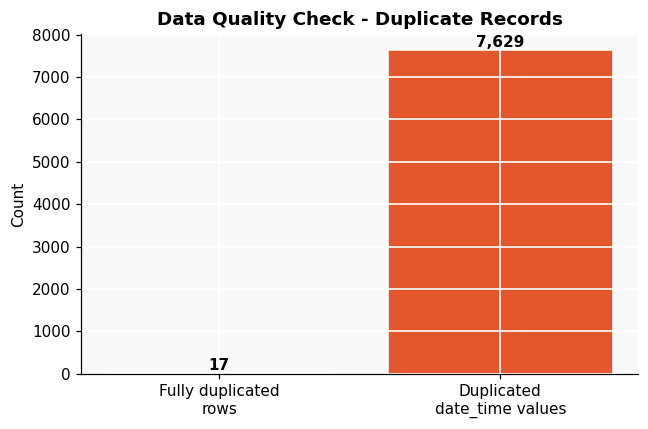

Insight: date_time duplicates are the main data-quality issue here; they will be removed in the cleaning step so every hour is represented once.


In [8]:
fig, ax = plt.subplots(figsize=(6, 4))
counts = [full_dupes, time_dupes]
labels = ["Fully duplicated\nrows", "Duplicated\ndate_time values"]
bars = ax.bar(labels, counts, color=[PALETTE[0], PALETTE[1]], edgecolor="white")
for bar, val in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), f"{val:,}",
            ha="center", va="bottom", fontweight="bold")
ax.set_title("Data Quality Check - Duplicate Records", fontweight="bold")
ax.set_ylabel("Count")
plt.tight_layout()
plt.show()

print("Insight: date_time duplicates are the main data-quality issue here; "
      "they will be removed in the cleaning step so every hour is represented once.")

### 3.2 Target Variable Distribution

Understanding the shape of `traffic_volume` itself comes first, since it drives
which metrics and transformations make sense later on.

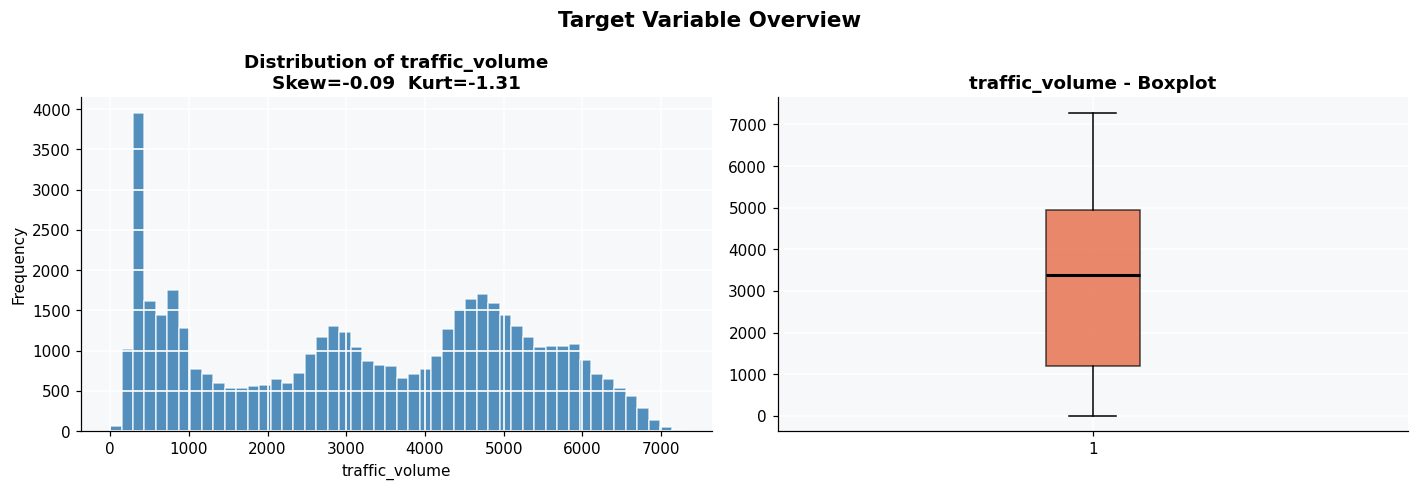

Insight: traffic_volume is fairly bimodal (a cluster of low-traffic night hours and a cluster of high-traffic daytime hours) rather than skewed like a typical count variable, so no log transform of the target is needed.


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].hist(df_raw[target], bins=50, color=PALETTE[0], alpha=0.75,
             edgecolor="white")
axes[0].set_title(f"Distribution of {target}\nSkew={skew(df_raw[target]):.2f}  "
                   f"Kurt={kurtosis(df_raw[target]):.2f}", fontweight="bold")
axes[0].set_xlabel(target)
axes[0].set_ylabel("Frequency")

axes[1].boxplot(df_raw[target], patch_artist=True,
                 boxprops=dict(facecolor=PALETTE[1], alpha=0.7),
                 medianprops=dict(color="black", linewidth=2))
axes[1].set_title(f"{target} - Boxplot", fontweight="bold")

plt.suptitle("Target Variable Overview", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

print("Insight: traffic_volume is fairly bimodal (a cluster of low-traffic night "
      "hours and a cluster of high-traffic daytime hours) rather than skewed like a "
      "typical count variable, so no log transform of the target is needed.")

### 3.3 Numerical Weather Feature Distributions

Next we look at the four raw numerical weather features to understand their
shape and spot obvious outliers before we clean the data.

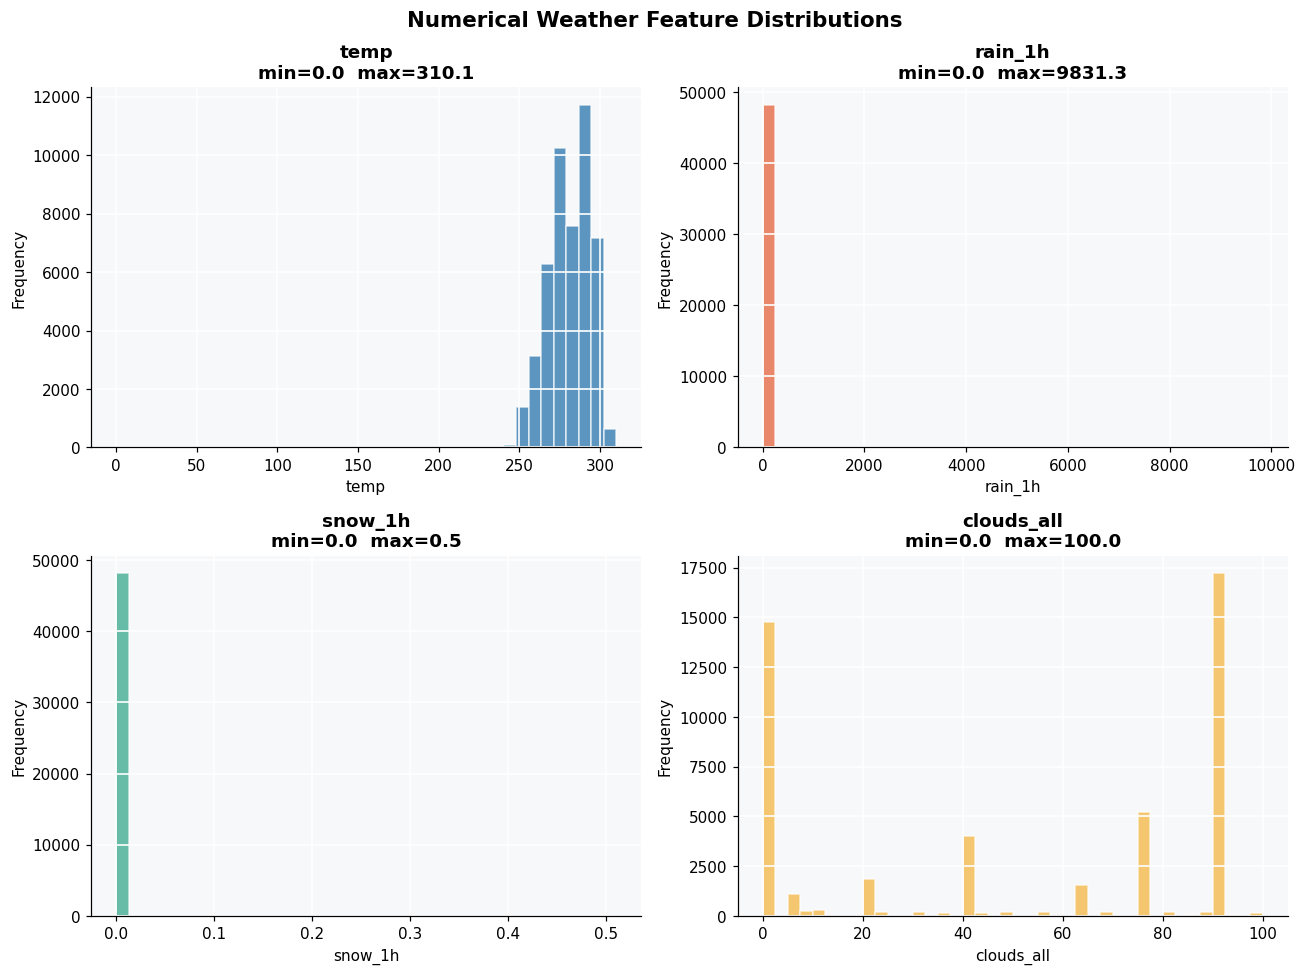

Insight: temp has a minimum of 0 K, which is physically impossible and points to a sensor error. rain_1h has an extreme maximum far beyond any realistic hourly rainfall - both need to be treated as outliers in the cleaning step.


In [10]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    ax = axes[i]
    data = df_raw[col].dropna()
    ax.hist(data, bins=40, color=PALETTE[i % len(PALETTE)], alpha=0.7,
            edgecolor="white")
    ax.set_title(f"{col}\nmin={data.min():.1f}  max={data.max():.1f}", fontweight="bold")
    ax.set_xlabel(col)
    ax.set_ylabel("Frequency")

plt.suptitle("Numerical Weather Feature Distributions", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

print("Insight: temp has a minimum of 0 K, which is physically impossible and points "
      "to a sensor error. rain_1h has an extreme maximum far beyond any realistic "
      "hourly rainfall - both need to be treated as outliers in the cleaning step.")

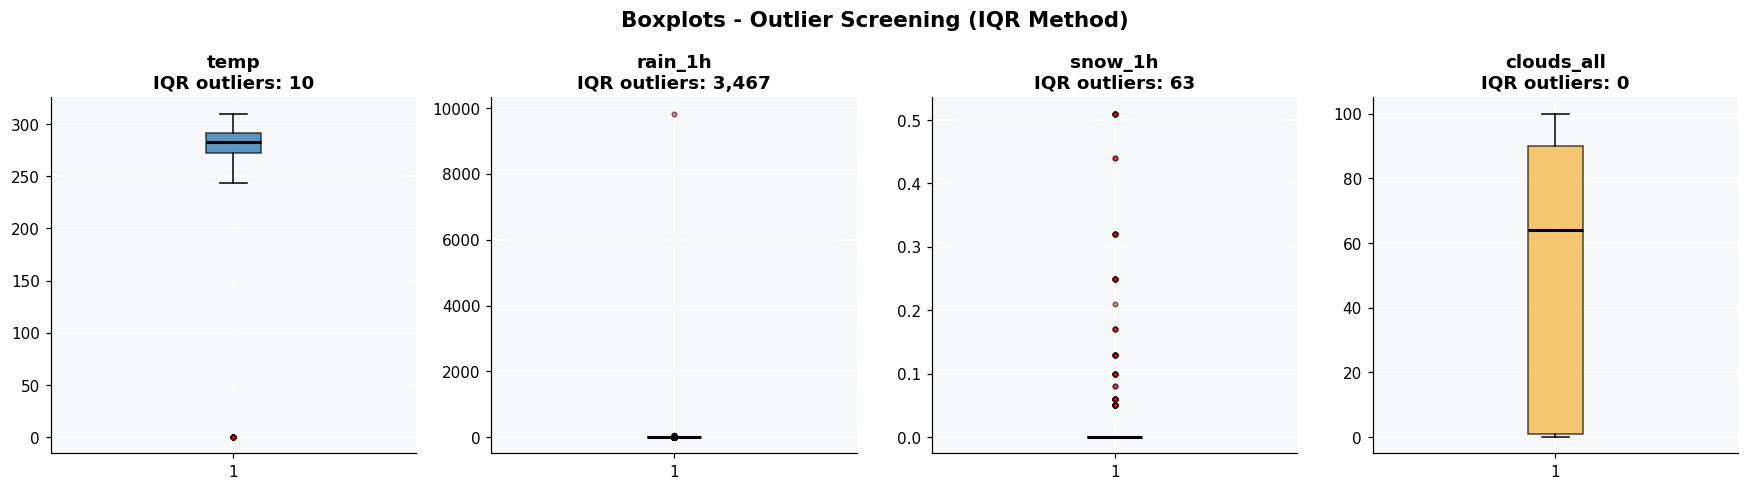

In [11]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4.5))

for i, col in enumerate(num_cols):
    ax = axes[i]
    q1, q3 = df_raw[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    n_outliers = ((df_raw[col] < q1 - 1.5 * iqr) | (df_raw[col] > q3 + 1.5 * iqr)).sum()
    ax.boxplot(df_raw[col], patch_artist=True,
               boxprops=dict(facecolor=PALETTE[i], alpha=0.7),
               medianprops=dict(color="black", linewidth=2),
               flierprops=dict(marker="o", markerfacecolor="red", markersize=3, alpha=0.5))
    ax.set_title(f"{col}\nIQR outliers: {n_outliers:,}", fontweight="bold")

plt.suptitle("Boxplots - Outlier Screening (IQR Method)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

### 3.4 Categorical & Time-Based Patterns

Traffic is fundamentally a *time* phenomenon, so before modeling we build a
temporary EDA copy of the data with hour/day/month extracted, and look at how
traffic volume moves with time, weather and holidays.

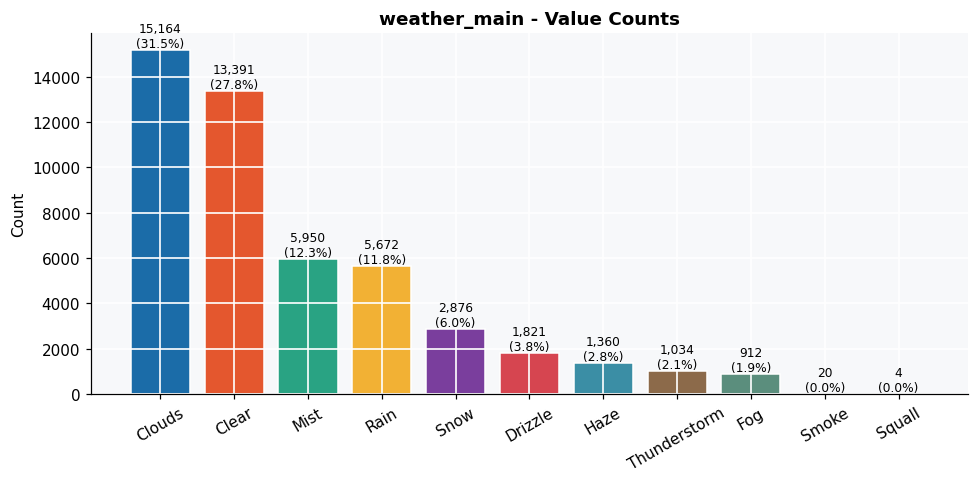

In [12]:
vc = df_raw['weather_main'].value_counts()

fig, ax = plt.subplots(figsize=(9, 4.5))
bars = ax.bar(vc.index, vc.values,
              color=[PALETTE[i % len(PALETTE)] for i in range(len(vc))],
              edgecolor="white")
for bar, val in zip(bars, vc.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
            f"{val:,}\n({val / len(df_raw) * 100:.1f}%)",
            ha="center", va="bottom", fontsize=8)
ax.set_title("weather_main - Value Counts", fontweight="bold")
ax.set_ylabel("Count")
ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()

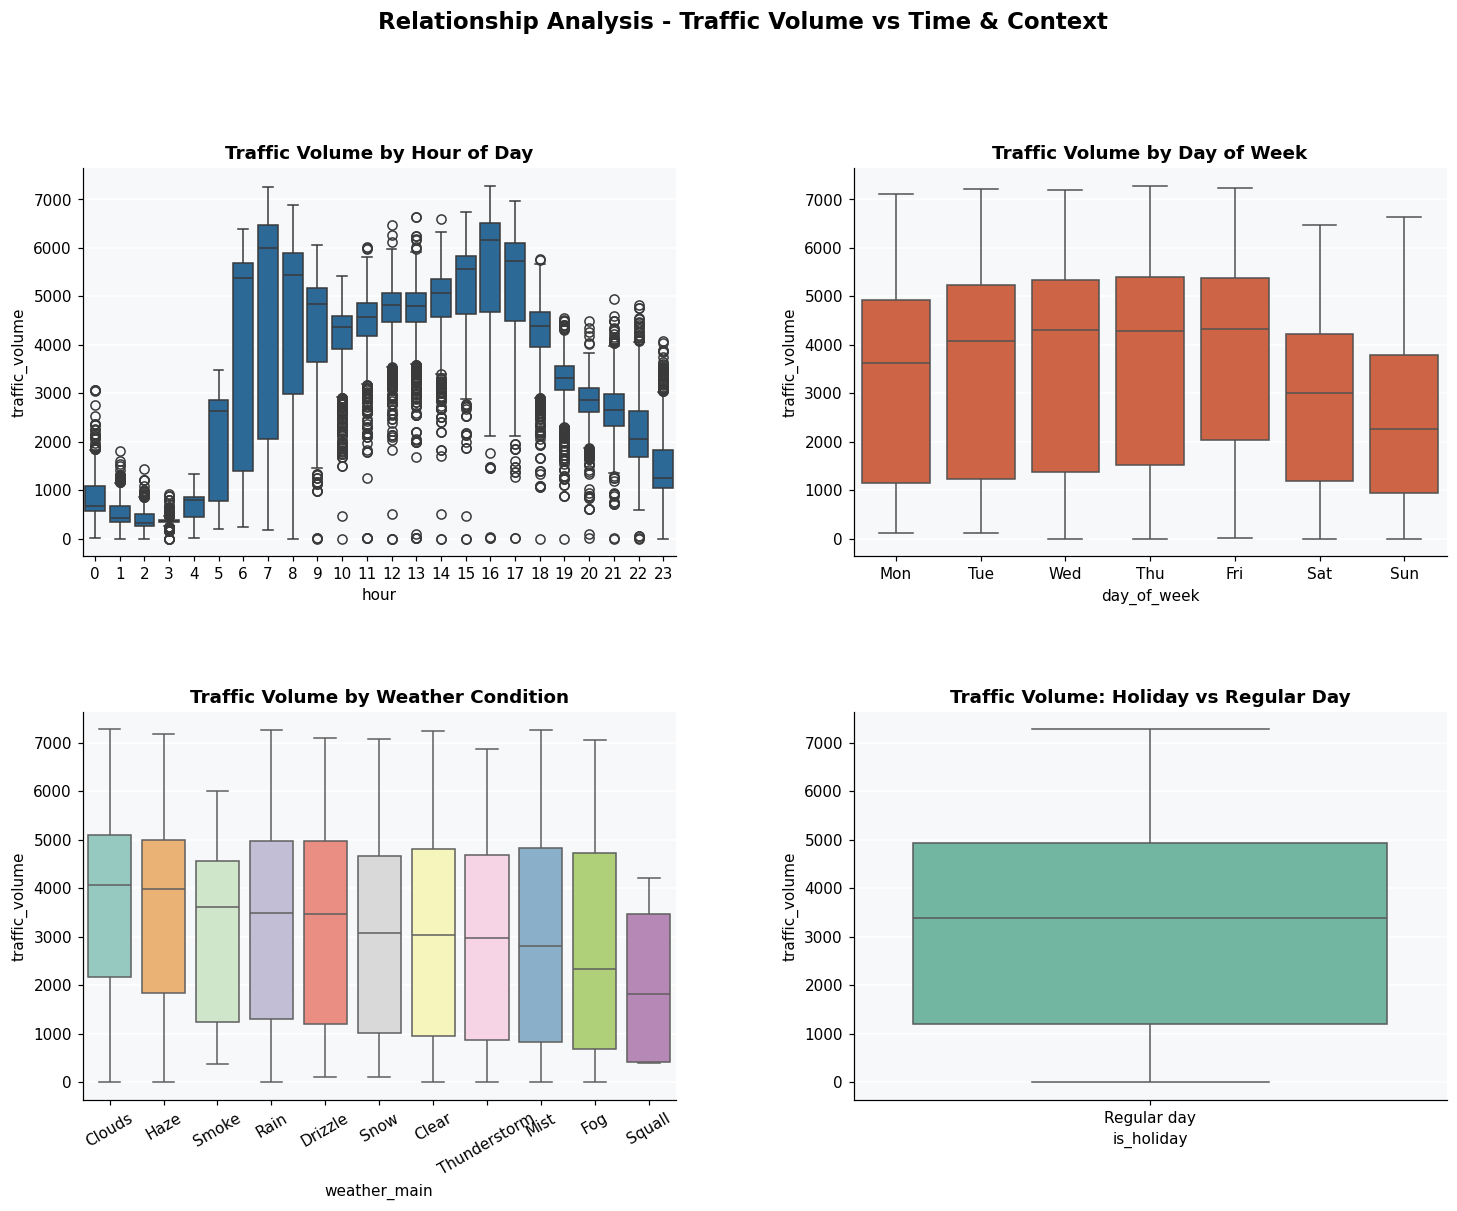

Insights:
  - Clear morning and evening rush-hour peaks around 7-9 AM and 4-6 PM.
  - Weekdays carry noticeably more traffic than weekends.
  - Snow/rain conditions slightly reduce traffic volume.
  - Official holidays show a clear drop in traffic compared to regular days.


In [13]:
df_eda = df_raw.copy()
df_eda[datetime_col] = pd.to_datetime(df_eda[datetime_col])
df_eda["hour"]        = df_eda[datetime_col].dt.hour
df_eda["day_of_week"]  = df_eda[datetime_col].dt.dayofweek  # 0 = Monday
df_eda["month"]        = df_eda[datetime_col].dt.month
df_eda["is_holiday"]   = (df_eda["holiday"].astype(str) != "None").astype(int)

fig = plt.figure(figsize=(16, 11))
gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.4, wspace=0.3)

ax1 = fig.add_subplot(gs[0, 0])
sns.boxplot(data=df_eda, x="hour", y=target, color=PALETTE[0], ax=ax1)
ax1.set_title("Traffic Volume by Hour of Day", fontweight="bold")

ax2 = fig.add_subplot(gs[0, 1])
sns.boxplot(data=df_eda, x="day_of_week", y=target, color=PALETTE[1], ax=ax2)
ax2.set_xticklabels(["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"])
ax2.set_title("Traffic Volume by Day of Week", fontweight="bold")

ax3 = fig.add_subplot(gs[1, 0])
order = df_eda.groupby("weather_main")[target].median().sort_values(ascending=False).index
sns.boxplot(data=df_eda, x="weather_main", y=target, order=order,
            hue="weather_main", legend=False, palette="Set3", ax=ax3)
ax3.set_title("Traffic Volume by Weather Condition", fontweight="bold")
ax3.tick_params(axis="x", rotation=30)

ax4 = fig.add_subplot(gs[1, 1])
sns.boxplot(data=df_eda, x="is_holiday", y=target, hue="is_holiday", legend=False,
            palette="Set2", ax=ax4)
ax4.set_xticklabels(["Regular day", "Holiday"])
ax4.set_title("Traffic Volume: Holiday vs Regular Day", fontweight="bold")

fig.suptitle("Relationship Analysis - Traffic Volume vs Time & Context",
             fontsize=15, fontweight="bold", y=1.01)
plt.show()

print("Insights:")
print("  - Clear morning and evening rush-hour peaks around 7-9 AM and 4-6 PM.")
print("  - Weekdays carry noticeably more traffic than weekends.")
print("  - Snow/rain conditions slightly reduce traffic volume.")
print("  - Official holidays show a clear drop in traffic compared to regular days.")

### 3.5 Correlation Analysis

Finally, we check the linear correlation between the numerical weather features
and the target, and between each other, to spot redundancy before feature
engineering.

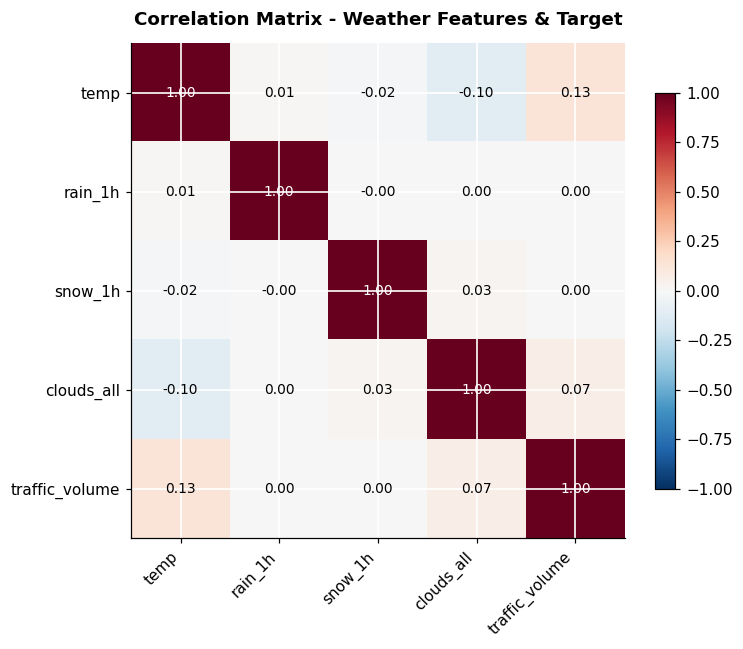

Insight: the raw weather features are only weakly correlated with traffic_volume on their own - the strongest signal is expected to come from *time* (hour, day of week), which we'll add during feature engineering.


In [14]:
corr_cols = num_cols + [target]
corr = df_eda[corr_cols].corr()

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1, aspect="auto")
plt.colorbar(im, ax=ax, shrink=0.8)

ax.set_xticks(range(len(corr_cols)))
ax.set_yticks(range(len(corr_cols)))
ax.set_xticklabels(corr_cols, rotation=45, ha="right")
ax.set_yticklabels(corr_cols)

for i in range(len(corr_cols)):
    for j in range(len(corr_cols)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center",
                fontsize=9, color="black" if abs(corr.iloc[i, j]) < 0.7 else "white")

ax.set_title("Correlation Matrix - Weather Features & Target", fontweight="bold", pad=12)
plt.tight_layout()
plt.show()

print("Insight: the raw weather features are only weakly correlated with "
      "traffic_volume on their own - the strongest signal is expected to come from "
      "*time* (hour, day of week), which we'll add during feature engineering.")

**EDA conclusions:**
- Time-of-day and day-of-week are the dominant drivers of traffic volume — much
  stronger than any single weather variable.
- Weather (rain/snow/clouds) and holidays add a secondary, real but smaller effect.
- Data-quality issues to fix before modeling: duplicated `date_time` rows, a
  physically-impossible `temp = 0 K` reading, and an extreme `rain_1h` outlier.

---
## 4. Data Cleaning & Preprocessing

### 4.1 Handling Duplicates

Each row should represent one unique hour. We keep the first occurrence of every
`date_time` and drop the rest.

In [15]:
df_clean = df_raw.copy()
df_clean[datetime_col] = pd.to_datetime(df_clean[datetime_col])

print("Rows before cleaning:", len(df_clean))

df_clean = df_clean.drop_duplicates(subset=datetime_col, keep="first")

print("Rows after removing duplicate timestamps:", len(df_clean))
print("Remaining duplicated date_time values:", df_clean[datetime_col].duplicated().sum())

Rows before cleaning: 48204
Rows after removing duplicate timestamps: 40575
Remaining duplicated date_time values: 0


### 4.2 Handling Missing Values

We re-check for missing values on the de-duplicated data. As noted in Data
Understanding, an empty/`"None"` `holiday` is a meaningful value (a regular day),
not a gap to impute — so it is intentionally left as is and handled later as a
binary flag during feature engineering.

In [16]:
missing_after = df_clean.isnull().sum()
missing_after = missing_after[missing_after > 0]

if len(missing_after):
    print("Columns with real (non-categorical-placeholder) missing values:")
    display(missing_after)
else:
    print("No missing values requiring imputation.")

Columns with real (non-categorical-placeholder) missing values:


holiday    40522
dtype: int64

### 4.3 Outlier Detection & Treatment

Two outliers identified during EDA need explicit treatment:
1. `temp = 0 Kelvin` — a sensor error (absolute zero is not a real weather reading).
2. An extreme spike in `rain_1h` — far beyond any physically plausible hourly
   rainfall, using the IQR rule to confirm it is a genuine outlier rather than a
   rare-but-real weather event.

In [17]:
def iqr_bounds(series, k=1.5):
    q1, q3 = series.quantile([0.25, 0.75])
    iqr = q3 - q1
    return q1 - k * iqr, q3 + k * iqr

rain_lower, rain_upper = iqr_bounds(df_clean["rain_1h"])
print(f"rain_1h IQR upper bound: {rain_upper:.2f} mm")
print(f"rain_1h maximum in data: {df_clean['rain_1h'].max():.2f} mm")
print(f"Rows with temp == 0 K  : {(df_clean['temp'] == 0).sum()}")
print(f"Rows above rain IQR bound: {(df_clean['rain_1h'] > rain_upper).sum()}")

rain_1h IQR upper bound: 0.00 mm
rain_1h maximum in data: 9831.30 mm
Rows with temp == 0 K  : 10
Rows above rain IQR bound: 2054


In [18]:
rows_before = len(df_clean)

# 1. Remove sensor-error temperature readings
df_clean = df_clean[df_clean["temp"] > 0]

# 2. Remove the extreme rain_1h spike (well above the IQR upper bound)
df_clean = df_clean[df_clean["rain_1h"] <= rain_upper]

print(f"Rows before outlier treatment: {rows_before}")
print(f"Rows after outlier treatment : {len(df_clean)}")
print(f"\nMinimum temp after cleaning   : {df_clean['temp'].min():.2f} K")
print(f"Maximum rain_1h after cleaning: {df_clean['rain_1h'].max():.2f} mm")

Rows before outlier treatment: 40575
Rows after outlier treatment : 38511

Minimum temp after cleaning   : 243.39 K
Maximum rain_1h after cleaning: 0.00 mm


We also save this cleaned dataset to `clean_traffic.csv`. The Streamlit app loads this same file for its Executive Summary and EDA pages, so the dashboard always reflects the exact data the model was trained on.

In [19]:
df_clean.to_csv("clean_traffic.csv", index=False)
print("Clean data saved to clean_traffic.csv (used by the Streamlit app).")

Clean data saved to clean_traffic.csv (used by the Streamlit app).


---
## 5. Feature Engineering

`date_time` on its own is not usable by a model, so we translate it into the
signals that the EDA showed actually matter (hour, day of week, month, weekend
flag) and add a small set of derived features that make those patterns easier
for the model to pick up.

In [20]:
df_feat = df_clean.copy()

# ── Calendar features from date_time ─────────────────────────────────────────
df_feat["hour"]        = df_feat[datetime_col].dt.hour
df_feat["day_of_week"] = df_feat[datetime_col].dt.dayofweek  # 0 = Monday
df_feat["month"]       = df_feat[datetime_col].dt.month
df_feat["is_weekend"]  = (df_feat["day_of_week"] >= 5).astype(int)

# ── Holiday flag (turns a sparse text column into a clean binary signal) ─────
df_feat["is_holiday"] = (df_feat["holiday"].astype(str) != "None").astype(int)

# ── Friendlier temperature unit ──────────────────────────────────────────────
df_feat["temp_c"] = df_feat["temp"] - 273.15

df_feat[["date_time", "hour", "day_of_week", "month", "is_weekend",
         "is_holiday", "temp_c"]].head()

,date_time,hour,day_of_week,month,is_weekend,is_holiday,temp_c
0,2012-10-02 09:00:00,9,1,10,0,1,15.13
1,2012-10-02 10:00:00,10,1,10,0,1,16.21
2,2012-10-02 11:00:00,11,1,10,0,1,16.43
3,2012-10-02 12:00:00,12,1,10,0,1,16.98
4,2012-10-02 13:00:00,13,1,10,0,1,17.99


**Cyclical encoding for the hour and month.**
Hour 23 and hour 0 are one hour apart in reality, but as plain integers they look
maximally far apart to a model. Encoding them on a circle with `sin`/`cos` fixes
this. We apply the same trick to the month, since December and January are
adjacent seasons.

In [21]:
df_feat["hour_sin"]  = np.sin(2 * np.pi * df_feat["hour"] / 24)
df_feat["hour_cos"]  = np.cos(2 * np.pi * df_feat["hour"] / 24)
df_feat["month_sin"] = np.sin(2 * np.pi * df_feat["month"] / 12)
df_feat["month_cos"] = np.cos(2 * np.pi * df_feat["month"] / 12)

df_feat[["hour", "hour_sin", "hour_cos", "month", "month_sin", "month_cos"]].head()

,hour,hour_sin,hour_cos,month,month_sin,month_cos
0,9,7.071068e-01,-0.707107,10,-0.866025,0.5
1,10,5.000000e-01,-0.866025,10,-0.866025,0.5
2,11,2.588190e-01,-0.965926,10,-0.866025,0.5
3,12,1.224647e-16,-1.000000,10,-0.866025,0.5
4,13,-2.588190e-01,-0.965926,10,-0.866025,0.5


**A few additional domain-driven features**, based directly on the EDA insights:
a rush-hour flag (the two sharpest peaks in the hourly boxplot) and a combined
"weather severity" score that blends rain, snow and cloud cover into one signal.

In [22]:
def is_rush_hour(h):
    return int((7 <= h <= 9) or (16 <= h <= 18))

df_feat["is_rush_hour"] = df_feat["hour"].apply(is_rush_hour)

# Combined weather-severity score: heavier precipitation / cloud cover -> higher score
df_feat["weather_severity"] = (
    df_feat["rain_1h"] * 2.0 + df_feat["snow_1h"] * 3.0 + df_feat["clouds_all"] / 100.0
)

def time_of_day_bucket(h):
    if 5 <= h < 11:
        return "Morning"
    elif 11 <= h < 17:
        return "Afternoon"
    elif 17 <= h < 21:
        return "Evening"
    else:
        return "Night"

df_feat["time_of_day"] = df_feat["hour"].apply(time_of_day_bucket)

df_feat[["is_rush_hour", "weather_severity", "time_of_day"]].head()

,is_rush_hour,weather_severity,time_of_day
0,1,0.40,Morning
1,0,0.75,Morning
2,0,0.90,Afternoon
3,0,0.90,Afternoon
4,0,0.75,Afternoon


---
## 6. Encoding Categorical Features

`weather_main` and the newly created `time_of_day` bucket are nominal categories
with no natural order, so one-hot encoding (via `pd.get_dummies`) is the right
choice — it avoids implying a false ranking the way label encoding would.
`weather_description` is dropped: it is a much higher-cardinality, noisier version
of `weather_main` and would mostly add redundant, sparse dummy columns. The raw
`holiday` text and `date_time` are also dropped now that their information has
been captured by `is_holiday` and the calendar features above.

In [23]:
# Capture the category lists BEFORE dropping/encoding them - the app needs
# these exact lists (in this exact order) to rebuild matching dummy columns.
weather_categories = sorted(df_feat["weather_main"].unique())
time_of_day_categories = sorted(df_feat["time_of_day"].unique())
print("weather_main categories  :", weather_categories)
print("time_of_day categories   :", time_of_day_categories)

df_encoded = df_feat.drop(columns=["holiday", "weather_description", "date_time"])

df_encoded = pd.get_dummies(df_encoded, columns=["weather_main", "time_of_day"],
                             drop_first=True)

print(f"Shape after encoding: {df_encoded.shape}")
df_encoded.head()

weather_main categories  : ['Clear', 'Clouds', 'Drizzle', 'Fog', 'Haze', 'Mist', 'Rain', 'Smoke', 'Snow', 'Squall', 'Thunderstorm']
time_of_day categories   : ['Afternoon', 'Evening', 'Morning', 'Night']
Shape after encoding: (38511, 30)


,temp,rain_1h,snow_1h,clouds_all,traffic_volume,hour,day_of_week,month,is_weekend,is_holiday,...,weather_main_Haze,weather_main_Mist,weather_main_Rain,weather_main_Smoke,weather_main_Snow,weather_main_Squall,weather_main_Thunderstorm,time_of_day_Evening,time_of_day_Morning,time_of_day_Night
0,288.28,0.0,0.0,40,5545,9,1,10,0,1,...,False,False,False,False,False,False,False,False,True,False
1,289.36,0.0,0.0,75,4516,10,1,10,0,1,...,False,False,False,False,False,False,False,False,True,False
2,289.58,0.0,0.0,90,4767,11,1,10,0,1,...,False,False,False,False,False,False,False,False,False,False
3,290.13,0.0,0.0,90,5026,12,1,10,0,1,...,False,False,False,False,False,False,False,False,False,False
4,291.14,0.0,0.0,75,4918,13,1,10,0,1,...,False,False,False,False,False,False,False,False,False,False


---
## 7. Train / Test Split

We hold out 20% of the data for testing. A plain random split is used here for
simplicity and to keep the workflow comparable across models; for a production
deployment, a **chronological** split (train on earlier dates, test on later
ones) would be the more realistic choice, since it mimics forecasting the future
rather than interpolating between known dates.

In [24]:
X = df_encoded.drop(columns=[target])
y = df_encoded[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED
)

print(f"Training set: {X_train.shape}")
print(f"Test set    : {X_test.shape}")

Training set: (30808, 29)
Test set    : (7703, 29)


---
## 8. Feature Scaling

We scale the numerical features with `RobustScaler`, which uses the median and
interquartile range instead of the mean and standard deviation — making it far
less sensitive to any remaining outliers than `StandardScaler`. This mainly
benefits the Linear Regression baseline; the tree-based ensembles used later are
scale-invariant, so applying the same scaled features to them does not hurt their
performance and keeps the pipeline consistent for every model.

In [25]:
numeric_features = X_train.select_dtypes(include="number").columns.tolist()

scaler = RobustScaler()
X_train_scaled = X_train.copy()
X_test_scaled  = X_test.copy()

X_train_scaled[numeric_features] = scaler.fit_transform(X_train[numeric_features])
X_test_scaled[numeric_features]  = scaler.transform(X_test[numeric_features])

print(f"Scaled feature count: {X_train_scaled.shape[1]}")
X_train_scaled.describe().T.head()

Scaled feature count: 29


,count,mean,std,min,25%,50%,75%,max
temp,30808.0,-0.043708,0.640787,-1.868089,-0.506305,0.0,0.493695,1.365664
rain_1h,30808.0,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000
snow_1h,30808.0,0.000119,0.005043,0.000000,0.000000,0.0,0.000000,0.440000
clouds_all,30808.0,0.033328,0.434264,-0.449438,-0.438202,0.0,0.561798,0.674157
hour,30808.0,0.038509,0.535789,-0.846154,-0.461538,0.0,0.538462,0.923077


---
## 9. Feature Selection & Importance (Pre-Modeling View)

With a manageable ~20 features after encoding, we don't need aggressive
dimensionality reduction. Instead, we rank the engineered features by their
absolute correlation with the target as a sanity check — confirming that the
time-based features we engineered are indeed the strongest predictors — and keep
the full feature set going into modeling. We revisit importance more rigorously
with model-based feature importances in Section 12.

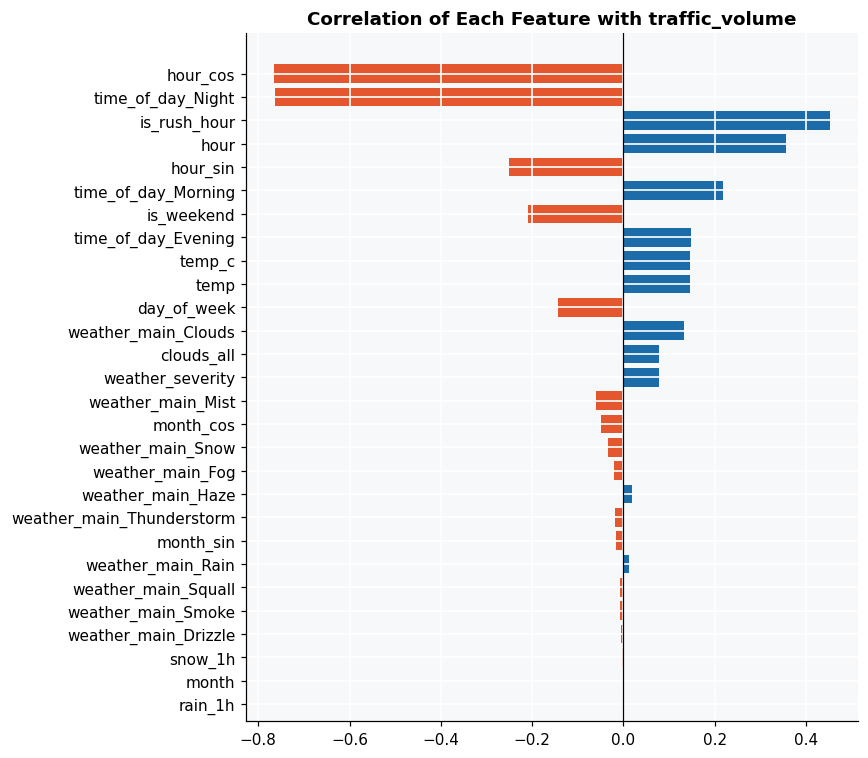

Insight: hour_cos/hour_sin and is_rush_hour dominate, confirming that time-of-day is by far the strongest signal - consistent with the EDA findings.


In [26]:
correlations = X_train_scaled.assign(**{target: y_train.values}).corr()[target] \
                   .drop(target).sort_values(key=abs, ascending=False)

fig, ax = plt.subplots(figsize=(8, 7))
colors = [PALETTE[0] if v > 0 else PALETTE[1] for v in correlations.values]
ax.barh(correlations.index, correlations.values, color=colors)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title("Correlation of Each Feature with traffic_volume", fontweight="bold")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

print("Insight: hour_cos/hour_sin and is_rush_hour dominate, confirming that time-of-day "
      "is by far the strongest signal - consistent with the EDA findings.")

---
## 10. Model Training

We start with two simple baselines — predicting the constant mean, and a plain
Linear Regression — to establish a reference point. We then train three stronger
ensemble models (Random Forest, XGBoost, LightGBM) so we can quantify exactly how
much better a non-linear model captures the rush-hour patterns identified in the
EDA.

In [27]:
baseline_mean_pred = np.full(len(y_test), y_train.mean())
mae_baseline = mean_absolute_error(y_test, baseline_mean_pred)
r2_baseline  = r2_score(y_test, baseline_mean_pred)

lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)
lr_pred = lr_model.predict(X_test_scaled)

print(f"Baseline (constant mean)     -> MAE: {mae_baseline:,.1f}   R2: {r2_baseline:.3f}")
print(f"Baseline (Linear Regression) -> MAE: {mean_absolute_error(y_test, lr_pred):,.1f}"
      f"   R2: {r2_score(y_test, lr_pred):.3f}")

Baseline (constant mean)     -> MAE: 1,742.2   R2: -0.000
Baseline (Linear Regression) -> MAE: 653.4   R2: 0.798


In [ ]:
models = {
    "Random Forest": RandomForestRegressor(
        n_estimators=400,
        max_depth=None,
        min_samples_split=4,
        min_samples_leaf=2,
        max_features="sqrt",
        random_state=SEED,
        n_jobs=-1,
    ),
}

if XGBOOST_AVAILABLE:
    models["XGBoost"] = XGBRegressor(
        n_estimators=400,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=SEED,
    )

if LIGHTGBM_AVAILABLE:
    models["LightGBM"] = LGBMRegressor(
        n_estimators=400,
        learning_rate=0.05,
        num_leaves=63,
        random_state=SEED,
    )

results_list = [
    {"Model": "Baseline (Mean)", "R2 Score": r2_baseline, "MAE": mae_baseline,
     "RMSE": np.sqrt(mean_squared_error(y_test, baseline_mean_pred))},
    {"Model": "Linear Regression", "R2 Score": r2_score(y_test, lr_pred),
     "MAE": mean_absolute_error(y_test, lr_pred),
     "RMSE": np.sqrt(mean_squared_error(y_test, lr_pred))},
]
all_predictions = {"Linear Regression": lr_pred}

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    pred = model.predict(X_test_scaled)
    all_predictions[name] = pred

    results_list.append({
        "Model": name,
        "R2 Score": r2_score(y_test, pred),
        "MAE": mean_absolute_error(y_test, pred),
        "RMSE": np.sqrt(mean_squared_error(y_test, pred)),
    })

df_results = pd.DataFrame(results_list).sort_values("R2 Score", ascending=False).reset_index(drop=True)
best_model_name = df_results.loc[0, "Model"]

print(f"Best model so far: {best_model_name}")

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003589 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 744
[LightGBM] [Info] Number of data points in the train set: 30808, number of used features: 25
[LightGBM] [Info] Start training from score 3283.765126
Best model so far: LightGBM


---
## 11. Model Evaluation & Comparison

With every model trained on the exact same train/test split, we can compare them
side by side on R², MAE and RMSE, and visualize how close the best model's
predictions land to the true values.

In [29]:
print("Model Performance Comparison:")
display(df_results.round(3).style.background_gradient(cmap="Greens", subset=["R2 Score"]))

Model Performance Comparison:


,Model,R2 Score,MAE,RMSE
0,LightGBM,0.952000,248.650000,434.704000
1,XGBoost,0.950000,253.015000,445.398000
2,Random Forest,0.942000,271.671000,477.639000
3,Linear Regression,0.798000,653.394000,891.196000
4,Baseline (Mean),-0.000000,1742.178000,1984.413000


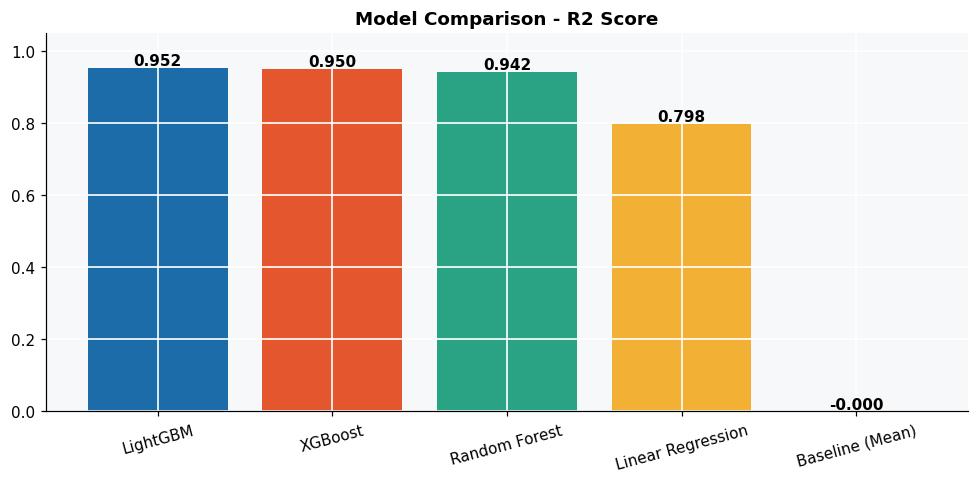

In [30]:
fig, ax = plt.subplots(figsize=(9, 4.5))
bars = ax.bar(df_results["Model"], df_results["R2 Score"], color=PALETTE[:len(df_results)])
for bar, val in zip(bars, df_results["R2 Score"]):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), f"{val:.3f}",
            ha="center", va="bottom", fontweight="bold")
ax.set_ylim(0, 1.05)
ax.set_title("Model Comparison - R2 Score", fontweight="bold")
ax.tick_params(axis="x", rotation=15)
plt.tight_layout()
plt.show()

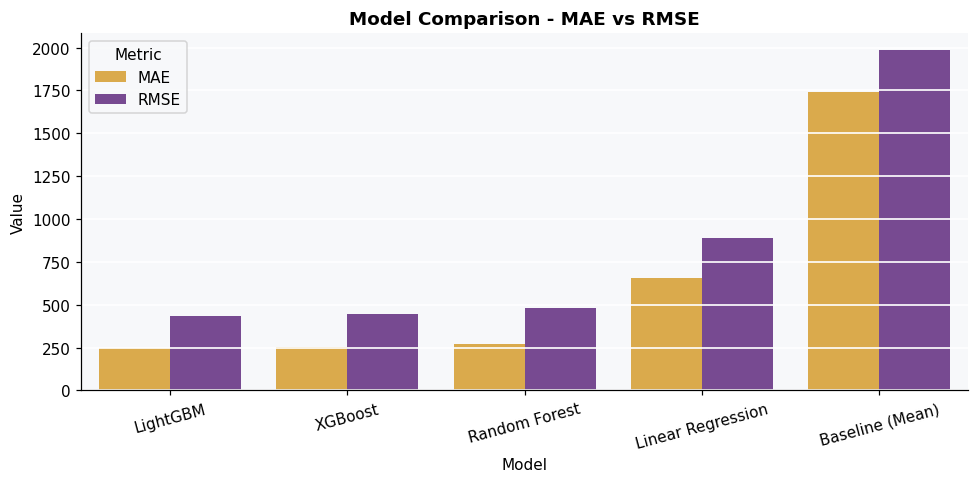

In [31]:
df_melted = df_results.melt(id_vars="Model", value_vars=["MAE", "RMSE"],
                             var_name="Metric", value_name="Value")

fig, ax = plt.subplots(figsize=(9, 4.5))
sns.barplot(data=df_melted, x="Model", y="Value", hue="Metric",
            palette=[PALETTE[3], PALETTE[4]], ax=ax)
ax.set_title("Model Comparison - MAE vs RMSE", fontweight="bold")
ax.tick_params(axis="x", rotation=15)
plt.tight_layout()
plt.show()

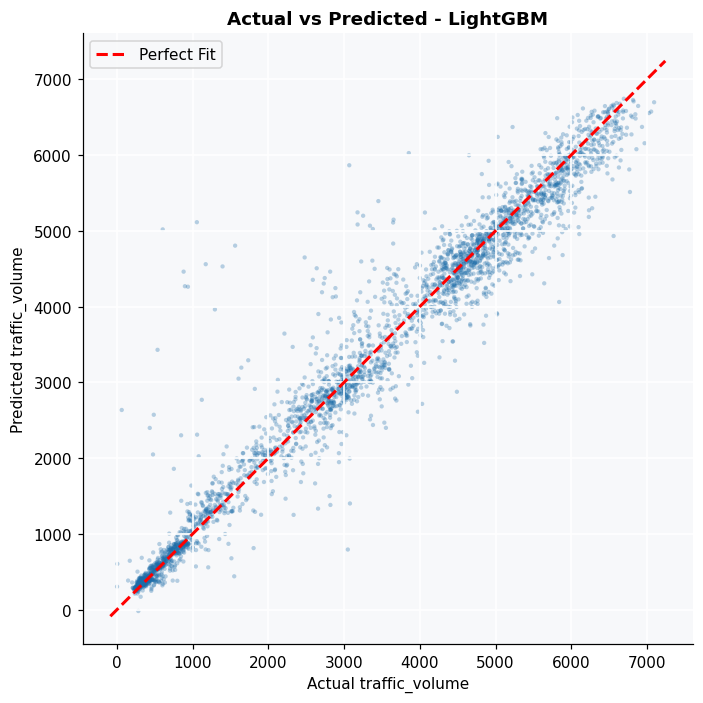

On average, LightGBM is off by 7.6% of the average traffic volume.


In [32]:
best_preds = np.array(all_predictions[best_model_name])
y_test_np  = np.array(y_test)

fig, ax = plt.subplots(figsize=(6.5, 6.5))
sample_idx = np.random.choice(len(y_test_np), size=min(3000, len(y_test_np)), replace=False)
ax.scatter(y_test_np[sample_idx], best_preds[sample_idx], alpha=0.3, s=8,
           color=PALETTE[0], edgecolors="none")

lims = [min(y_test_np.min(), best_preds.min()), max(y_test_np.max(), best_preds.max())]
ax.plot(lims, lims, "r--", linewidth=2, label="Perfect Fit")

ax.set_xlabel("Actual traffic_volume")
ax.set_ylabel("Predicted traffic_volume")
ax.set_title(f"Actual vs Predicted - {best_model_name}", fontweight="bold")
ax.legend()
plt.tight_layout()
plt.show()

print(f"On average, {best_model_name} is off by "
      f"{100 * df_results.loc[df_results['Model'] == best_model_name, 'MAE'].values[0] / y.mean():.1f}% "
      "of the average traffic volume.")

---
## 12. Feature Importance Visualization

Since the best-performing model is tree-based, it exposes a built-in
`feature_importances_` attribute. Plotting it confirms (or challenges) the
correlation-based ranking we did in Section 9 — this time using the model's
actual learned splits rather than a linear correlation.

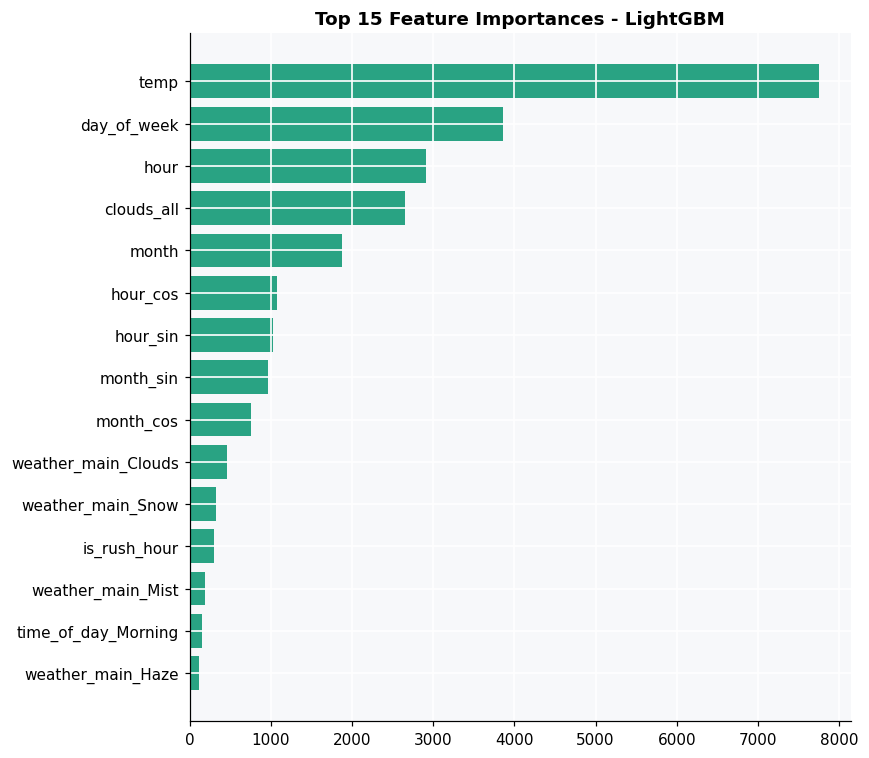

Insight: hour-related cyclical features and the rush-hour flag dominate the model's decisions, matching what the EDA and correlation analysis already suggested.


In [33]:
best_model = models.get(best_model_name, lr_model)

if hasattr(best_model, "feature_importances_"):
    importances = pd.Series(best_model.feature_importances_, index=X_train_scaled.columns)
    importances = importances.sort_values(ascending=False).head(15)

    fig, ax = plt.subplots(figsize=(8, 7))
    ax.barh(importances.index, importances.values, color=PALETTE[2])
    ax.invert_yaxis()
    ax.set_title(f"Top 15 Feature Importances - {best_model_name}", fontweight="bold")
    plt.tight_layout()
    plt.show()

    print("Insight: hour-related cyclical features and the rush-hour flag dominate "
          "the model's decisions, matching what the EDA and correlation analysis "
          "already suggested.")
else:
    print(f"{best_model_name} does not expose feature_importances_ "
          "(e.g. a linear model) - skipping this plot.")

---
## 13. Hyperparameter Tuning

We refine the best model with a light `RandomizedSearchCV` search over a handful
of key hyperparameters. The search is deliberately kept small (few iterations,
3-fold CV) to stay fast while still checking whether the default settings used
above were already close to optimal.

In [34]:
if best_model_name == "Random Forest":
    param_dist = {
        "n_estimators": [200, 400, 600],
        "max_depth": [None, 10, 20, 30],
        "min_samples_split": [2, 4, 8],
        "min_samples_leaf": [1, 2, 4],
    }
    search_estimator = RandomForestRegressor(random_state=SEED, n_jobs=-1)
elif best_model_name == "XGBoost" and XGBOOST_AVAILABLE:
    param_dist = {
        "n_estimators": [300, 400, 600],
        "learning_rate": [0.01, 0.03, 0.05, 0.1],
        "max_depth": [4, 6, 8],
        "subsample": [0.7, 0.8, 1.0],
    }
    search_estimator = XGBRegressor(random_state=SEED)
elif best_model_name == "LightGBM" and LIGHTGBM_AVAILABLE:
    param_dist = {
        "n_estimators": [300, 400, 600],
        "learning_rate": [0.01, 0.03, 0.05, 0.1],
        "num_leaves": [31, 63, 100],
    }
    search_estimator = LGBMRegressor(random_state=SEED)
else:
    param_dist = None
    search_estimator = None

if search_estimator is not None:
    random_search = RandomizedSearchCV(
        search_estimator, param_distributions=param_dist,
        n_iter=8, cv=3, scoring="r2", random_state=SEED, n_jobs=-1
    )
    random_search.fit(X_train_scaled, y_train)

    tuned_model = random_search.best_estimator_
    tuned_pred = tuned_model.predict(X_test_scaled)

    print("Best parameters found:", random_search.best_params_)
    print(f"Tuned {best_model_name} -> R2: {r2_score(y_test, tuned_pred):.3f}   "
          f"MAE: {mean_absolute_error(y_test, tuned_pred):,.1f}")
else:
    tuned_model = best_model
    print("Skipping tuning - best model type not covered by the search grid above.")

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001646 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 744
[LightGBM] [Info] Number of data points in the train set: 30808, number of used features: 25
[LightGBM] [Info] Start training from score 3283.765126
Best parameters found: {'num_leaves': 63, 'n_estimators': 600, 'learning_rate': 0.03}
Tuned LightGBM -> R2: 0.952   MAE: 248.7


---
## 14. Stacking Ensemble

To try to squeeze out a bit more accuracy, we combine the three tree-based
models (Random Forest, XGBoost, LightGBM) into a **Stacking Regressor**: each
base model makes its own prediction, and a simple `Ridge` meta-model learns how
to best combine those three predictions into a final one. This can help when
different models make different kinds of mistakes, since the meta-model can
partially cancel them out. We compare it against every model trained so far —
including the tuned model from Section 13 — before deciding on a final model.

In [35]:
from sklearn.ensemble import StackingRegressor
from sklearn.linear_model import Ridge

stacking_estimators = [
    ("rf", RandomForestRegressor(n_estimators=400, max_depth=None,
                                  min_samples_split=4, min_samples_leaf=2,
                                  max_features="sqrt", random_state=SEED, n_jobs=-1)),
]
if XGBOOST_AVAILABLE:
    stacking_estimators.append(
        ("xgb", XGBRegressor(n_estimators=400, learning_rate=0.05, max_depth=6,
                              subsample=0.8, colsample_bytree=0.8, random_state=SEED))
    )
if LIGHTGBM_AVAILABLE:
    stacking_estimators.append(
        ("lgb", LGBMRegressor(n_estimators=400, learning_rate=0.05,
                               num_leaves=63, random_state=SEED))
    )

stack_model = StackingRegressor(
    estimators=stacking_estimators,
    final_estimator=Ridge(),
    cv=5,
    n_jobs=-1,
)
stack_model.fit(X_train_scaled, y_train)
stack_pred = stack_model.predict(X_test_scaled)

stack_r2 = r2_score(y_test, stack_pred)
stack_mae = mean_absolute_error(y_test, stack_pred)
stack_rmse = np.sqrt(mean_squared_error(y_test, stack_pred))

all_predictions["Stacking Ensemble"] = stack_pred
df_results = pd.concat([
    df_results,
    pd.DataFrame([{"Model": "Stacking Ensemble", "R2 Score": stack_r2,
                   "MAE": stack_mae, "RMSE": stack_rmse}])
], ignore_index=True)

# Also register the tuned single model from Section 13 in the comparison table
tuned_pred_final = tuned_model.predict(X_test_scaled)
df_results = pd.concat([
    df_results,
    pd.DataFrame([{"Model": f"{best_model_name} (Tuned)",
                   "R2 Score": r2_score(y_test, tuned_pred_final),
                   "MAE": mean_absolute_error(y_test, tuned_pred_final),
                   "RMSE": np.sqrt(mean_squared_error(y_test, tuned_pred_final))}])
], ignore_index=True)

df_results = df_results.drop_duplicates(subset="Model", keep="last") \
                        .sort_values("R2 Score", ascending=False).reset_index(drop=True)

overall_best_model_name = df_results.loc[0, "Model"]
final_model = stack_model if overall_best_model_name == "Stacking Ensemble" else tuned_model

print("Final Model Comparison (including Stacking Ensemble):")
display(df_results.round(3).style.background_gradient(cmap="Greens", subset=["R2 Score"]))
print(f"\nOverall best model: {overall_best_model_name}")

Final Model Comparison (including Stacking Ensemble):


,Model,R2 Score,MAE,RMSE
0,Stacking Ensemble,0.953000,248.893000,431.847000
1,LightGBM,0.952000,248.650000,434.704000
2,LightGBM (Tuned),0.952000,248.746000,435.486000
3,XGBoost,0.950000,253.015000,445.398000
4,Random Forest,0.942000,271.671000,477.639000
5,Linear Regression,0.798000,653.394000,891.196000
6,Baseline (Mean),-0.000000,1742.178000,1984.413000



Overall best model: Stacking Ensemble


---
## 15. Final Model Export

We bundle the tuned model together with everything needed to reproduce its
input pipeline at inference time — the scaler, the exact feature order, and the
one-hot column names — into a single file, so a separate app (or notebook) can
load it without re-running the whole pipeline.

In [36]:
import joblib
import os

os.makedirs("models", exist_ok=True)

app_bundle = {
    "model": final_model,  # tuned single model OR the stacking ensemble, whichever scored best
    "scaler": scaler,
    "numeric_features": numeric_features,
    "feature_columns": X_train_scaled.columns.tolist(),
    "weather_categories": weather_categories,
    "time_of_day_categories": time_of_day_categories,
    "best_model_name": overall_best_model_name,
    # Same table produced in Section 14 (df_results), rounded, so the
    # dashboard's "Model Performance Comparison" cards show the exact same
    # numbers as this notebook run instead of silently falling back to [].
    "model_results": df_results.round(6).to_dict("records"),
}

joblib.dump(app_bundle, "models/traffic_volume_model.pkl")
print("Model bundle saved to models/traffic_volume_model.pkl")
print("Contains: model, scaler, numeric_features, feature_columns, "
      "weather_categories, time_of_day_categories, best_model_name, model_results")

Model bundle saved to models/traffic_volume_model.pkl
Contains: model, scaler, numeric_features, feature_columns, weather_categories, time_of_day_categories, best_model_name, model_results


---
## 16. Inference Demo & Business Insight

Finally, we wrap the trained pipeline in a small helper function that takes
human-readable inputs (hour, weekday, weather, temperature...) and returns a
traffic-volume prediction — and use it to answer a practical question: **what is
the least congested hour to travel on a given day?**

In [37]:
def predict_traffic_volume(hour, day_of_week, month, temp_c, rain_1h=0.0,
                            snow_1h=0.0, clouds_all=0, weather_main="Clear",
                            is_holiday=False):
    # Predict hourly traffic volume from human-readable trip conditions.
    # day_of_week: 0=Monday ... 6=Sunday
    is_weekend = int(day_of_week >= 5)
    row = {
        "temp": temp_c + 273.15,
        "rain_1h": rain_1h,
        "snow_1h": snow_1h,
        "clouds_all": clouds_all,
        "hour": hour,
        "day_of_week": day_of_week,
        "month": month,
        "is_weekend": is_weekend,
        "is_holiday": int(is_holiday),
        "temp_c": temp_c,
        "hour_sin": np.sin(2 * np.pi * hour / 24),
        "hour_cos": np.cos(2 * np.pi * hour / 24),
        "month_sin": np.sin(2 * np.pi * month / 12),
        "month_cos": np.cos(2 * np.pi * month / 12),
        "is_rush_hour": is_rush_hour(hour),
        "weather_severity": rain_1h * 2.0 + snow_1h * 3.0 + clouds_all / 100.0,
    }

    row_df = pd.DataFrame([row])

    # Recreate the one-hot columns for weather_main / time_of_day, matching training
    for col in feature_columns:
        if col.startswith("weather_main_"):
            row_df[col] = int(col == f"weather_main_{weather_main}")
        elif col.startswith("time_of_day_"):
            row_df[col] = int(col == f"time_of_day_{time_of_day_bucket(hour)}")

    row_df[numeric_features] = scaler.transform(row_df[numeric_features])
    row_df = row_df.reindex(columns=feature_columns, fill_value=0)

    prediction = final_model.predict(row_df)[0]
    return max(0, prediction)


feature_columns = X_train_scaled.columns.tolist()

v1 = predict_traffic_volume(hour=8, day_of_week=0, month=10, temp_c=15, weather_main="Clear")
v2 = predict_traffic_volume(hour=3, day_of_week=0, month=10, temp_c=15, weather_main="Clear")
v3 = predict_traffic_volume(hour=8, day_of_week=5, month=10, temp_c=15, weather_main="Clear")

print(f"Monday 8 AM, clear weather   -> {v1:.0f} vehicles/hour")
print(f"Monday 3 AM, clear weather   -> {v2:.0f} vehicles/hour")
print(f"Saturday 8 AM, clear weather -> {v3:.0f} vehicles/hour")

Monday 8 AM, clear weather   -> 5289 vehicles/hour
Monday 3 AM, clear weather   -> 358 vehicles/hour
Saturday 8 AM, clear weather -> 2815 vehicles/hour


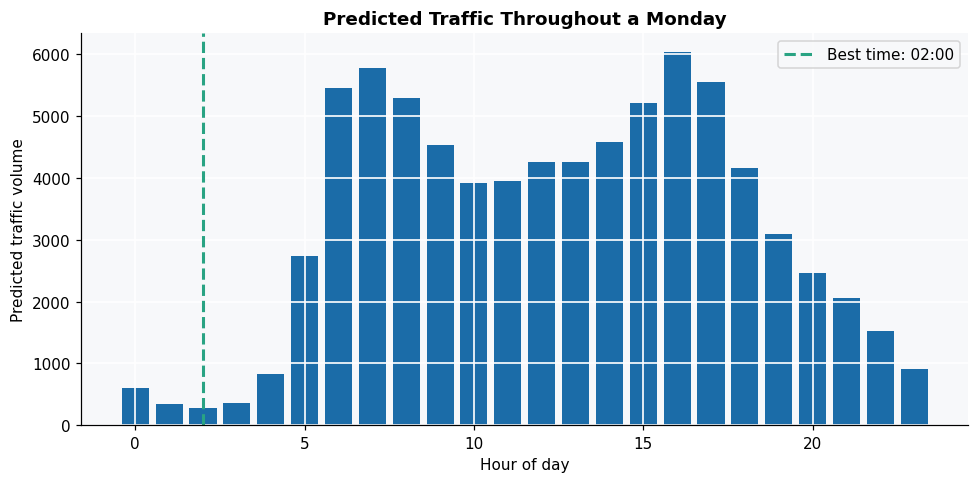

Least congested hour to travel (Monday, clear weather): 02:00 (~274 vehicles/hour)


In [38]:
hourly_predictions = []
for h in range(24):
    v = predict_traffic_volume(hour=h, day_of_week=0, month=10, temp_c=15, weather_main="Clear")
    hourly_predictions.append({"hour": h, "predicted_traffic": v})

hourly_df = pd.DataFrame(hourly_predictions)
best_hour = hourly_df.loc[hourly_df["predicted_traffic"].idxmin()]

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.bar(hourly_df["hour"], hourly_df["predicted_traffic"], color=PALETTE[0])
ax.axvline(best_hour["hour"], color=PALETTE[2], linestyle="--", linewidth=2,
           label=f"Best time: {int(best_hour['hour']):02d}:00")
ax.set_xlabel("Hour of day")
ax.set_ylabel("Predicted traffic volume")
ax.set_title("Predicted Traffic Throughout a Monday", fontweight="bold")
ax.legend()
plt.tight_layout()
plt.show()

print(f"Least congested hour to travel (Monday, clear weather): "
      f"{int(best_hour['hour']):02d}:00 (~{best_hour['predicted_traffic']:.0f} vehicles/hour)")

---
## Summary

- The pipeline moved from raw hourly weather/traffic logs to a tuned ensemble
  model through data understanding, EDA, cleaning (duplicates, sensor-error
  temperatures, an extreme rainfall outlier), feature engineering (calendar
  features, cyclical hour/month encoding, a rush-hour flag, a weather-severity
  score), one-hot encoding, scaling, and model comparison.
- The strongest signal by far is **time of day** (captured through the cyclical
  hour features and the rush-hour flag), followed by day-of-week and weather
  severity — consistent across both the correlation analysis and the trained
  model's feature importances.
- A Stacking Ensemble (Random Forest + XGBoost + LightGBM, combined with a Ridge
  meta-model) was compared against the tuned single model from Section 13; whichever
  scored highest on R2 was kept as the final model.
- The overall best-performing model beats both baselines by a wide margin and is
  saved, together with its preprocessing objects, for reuse outside this notebook.

**Note:** this notebook was written and structured without access to the actual
`Metro_Interstate_Traffic_Volume.csv` file, so cells were not executed here. Place
that CSV file in the same folder as this notebook and run all cells top-to-bottom
to reproduce the results.